# Classificação da qualidade do sono a partir do hipnograma (Galaxy Watch4)

**PUCPR — Mineração de Séries Temporais — Prof. Vinícius M. A. Souza**
**Trabalho final: Coleta de dados e classificação de séries temporais**
Aluno: Pedro

**Links**
- Conjunto de dados: `COLE_AQUI_O_LINK_DO_REPOSITORIO`
- Este notebook (Colab): `COLE_AQUI_O_LINK_DO_COLAB`

**Problema.** Cada exemplo é **uma noite de sono** registrada pelo smartwatch, representada como uma série temporal **univariada**: a "profundidade" do sono ao longo das primeiras 8 horas após adormecer (o hipnograma). A pergunta é: *só pela forma dessa série, é possível dizer se a noite foi ruim, regular ou boa?*

| Classe | Critério (sleep score do Samsung Health) |
|---|---|
| `ruim` | score ≤ 69 |
| `regular` | 70 a 84 |
| `bom` | score ≥ 85 |

O classificador escolhido (**MiniRocket**) é comparado ao baseline pedido (**1NN com distância DTW**), usando acurácia e matriz de confusão.

## 0. Como executar

O notebook tem dois modos de obter os dados:

- **Modo A (padrão, para avaliação):** baixa o conjunto já pronto do repositório público (`URL_DADOS`). Basta executar todas as células (*Ambiente de execução → Executar tudo*).
- **Modo B (reconstrução):** refaz o conjunto do zero a partir do arquivo `.zip` exportado pelo Samsung Health (`CONSTRUIR_DO_ZERO = True`). Serve para documentar e reproduzir a etapa de coleta.

In [2]:
# Instala a biblioteca aeon, especializada em aprendizado de máquina para séries temporais.
# Fixamos a versão para que o resultado seja o mesmo em qualquer execução (reprodutibilidade).
!pip install -q aeon==1.6.0

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\terriped\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# ---------------------------------------------------------------
# Importações
# ---------------------------------------------------------------
import io, os, re, shutil, zipfile

import numpy as np                      # vetores e matrizes numéricas
import pandas as pd
import matplotlib.pyplot as plt         # gráficos
from scipy.stats import binomtest       # teste estatístico usado na comparação dos modelos

from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import StratifiedKFold

# Da aeon usamos: o 1-vizinho mais próximo (baseline), o MiniRocket e a função que calcula DTW
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
from aeon.classification.convolution_based import MiniRocketClassifier
from aeon.distances import dtw_pairwise_distance

import warnings
warnings.filterwarnings("ignore")        # esconde avisos técnicos do numba que não afetam o resultado

# Semente aleatória fixa: o MiniRocket sorteia parâmetros internos, e a semente garante resultados iguais
SEMENTE = 42
np.random.seed(SEMENTE)

In [2]:
# ---------------------------------------------------------------
# Configurações do experimento (tudo que define o protocolo fica aqui)
# ---------------------------------------------------------------

# Modo A: endereço "raw" da pasta 'dados' no GitHub (substitua pelo seu repositório)
URL_DADOS = "https://raw.githubusercontent.com/SEU_USUARIO/SEU_REPOSITORIO/main/dados"

# Modo B: reconstruir a partir da exportação do Samsung Health (faça upload do .zip no Colab)
CONSTRUIR_DO_ZERO = False
CAMINHO_EXPORT = "/content/samsung_health_export.zip"

# Protocolo de construção das séries
DURACAO_MINIMA_MIN = 180   # descartamos registros com menos de 3 h (cochilos, noites incompletas)
EPOCA_MIN = 5              # segmentação: cada ponto da série resume 5 minutos de sono
JANELA_HORAS = 8           # trimming/padding: todas as séries cobrem as 8 h após adormecer
N_PONTOS = JANELA_HORAS * 60 // EPOCA_MIN   # = 96 pontos por série

# Rotulação: limites do sleep score para cada classe
CLASSES = ["ruim", "regular", "bom"]
LIMITES_SCORE = [0, 69, 84, 100]           # (0,69] ruim | (69,84] regular | (84,100] bom

# Divisão treino/teste temporal: noites antes desta data = treino; a partir dela = teste
DATA_CORTE = "2025-04-01"

# Codificação dos estágios do sono (códigos do Samsung Health -> profundidade)
PROFUNDIDADE = {40001: 0,   # acordado
                40004: 1,   # REM
                40002: 2,   # sono leve
                40003: 3}   # sono profundo
NOMES_ESTAGIOS = ["Acordado", "REM", "Leve", "Profundo"]
print(f"Cada série terá {N_PONTOS} pontos ({JANELA_HORAS} h em épocas de {EPOCA_MIN} min).")

Cada série terá 96 pontos (8 h em épocas de 5 min).


## 1. Coleta e construção do conjunto de dados

**Protocolo de coleta.** Os dados foram registrados passivamente por um **Samsung Galaxy Watch4**, usado no pulso durante o sono, entre outubro de 2023 e setembro de 2026. O relógio combina acelerômetro e frequência cardíaca para estimar, minuto a minuto, o estágio do sono (acordado, REM, leve, profundo), e o app Samsung Health atribui a cada noite um *sleep score* de 0 a 100. Os dados foram exportados pelo próprio app (*Configurações → Baixar dados pessoais*), que gera um `.zip` com um CSV por tipo de medição.

**Arquivos usados da exportação**
- `com.samsung.shealth.sleep.*.csv`: uma linha por sessão de sono (início, fim, sleep score).
- `com.samsung.health.sleep_stage.*.csv`: os trechos de cada estágio, ligados à sessão pela coluna `sleep_id`.

**Decisões do protocolo**
1. Horários convertidos de UTC para o horário local, usando a coluna `time_offset` de cada registro.
2. Cada noite é identificada pela data em que a pessoa **acordou**; se houver mais de uma sessão nessa data, fica a mais longa (a principal).
3. Sessões com menos de 3 h são descartadas, pois são cochilos ou registros interrompidos.
4. Uma noite gera **um único exemplo**, então não há sobreposição entre exemplos.

As funções abaixo implementam cada etapa; a execução acontece na célula 1.5 (apenas no Modo B).

In [4]:
# 1.1 Leitura dos CSVs de dentro do .zip exportado

def ler_tabela(zf, padrao):
    """Lê do .zip o CSV cujo nome casa com a expressão regular 'padrao'.
    - skiprows=1: a 1ª linha de cada CSV do Samsung Health é um cabeçalho técnico
      (nome da tabela e versão), não os nomes das colunas.
    - index_col=False: as linhas terminam com uma vírgula a mais; sem isso o pandas
      desalinharia as colunas."""
    nome = next(n for n in zf.namelist() if re.match(padrao, n))
    return pd.read_csv(io.BytesIO(zf.read(nome)), skiprows=1, index_col=False)

def para_horario_local(tempos_utc, offsets):
    """Converte horários UTC para o horário local.
    'offsets' vem no formato 'UTC-0300' -> -3 horas."""
    def horas(txt):
        sinal = -1 if txt[3] == "-" else 1
        return sinal * (int(txt[4:6]) + int(txt[6:8]) / 60)
    return pd.to_datetime(tempos_utc) + pd.to_timedelta(offsets.map(horas), unit="h")

In [5]:
# 1.2 Seleção das noites válidas

def selecionar_noites(sono):
    p = "com.samsung.health.sleep."        # prefixo dos nomes de coluna nessa tabela
    noites = pd.DataFrame({
        "sleep_id":    sono[p + "datauuid"],
        "inicio":      para_horario_local(sono[p + "start_time"], sono[p + "time_offset"]),
        "fim":         para_horario_local(sono[p + "end_time"],   sono[p + "time_offset"]),
        "sleep_score": sono["sleep_score"],
    })
    noites["duracao_min"] = (noites["fim"] - noites["inicio"]).dt.total_seconds() / 60
    noites["noite"] = noites["fim"].dt.normalize()            # data do despertar

    noites = noites.dropna(subset=["sleep_score"])             # sem score = sem rótulo
    noites = (noites.sort_values("duracao_min")                # mais longa por data
                    .groupby("noite").tail(1))
    noites = noites[noites["duracao_min"] >= DURACAO_MINIMA_MIN]
    return noites.sort_values("noite").reset_index(drop=True)

In [6]:
# 1.3 Construção da série de cada noite: hipnograma -> segmentação -> trimming/padding

def hipnograma_por_minuto(noite, trechos):
    """Monta uma série com 1 valor por minuto, entre o início e o fim da sessão.
    Minutos sem nenhum trecho registrado recebem 0 (acordado)."""
    minutos = pd.date_range(noite["inicio"], noite["fim"], freq="1min", inclusive="left")
    serie = pd.Series(0.0, index=minutos)
    for _, t in trechos.iterrows():
        dentro = (serie.index >= t["inicio"]) & (serie.index < t["fim"])
        serie[dentro] = t["profundidade"]
    return serie

def segmentar_e_ajustar(serie_minutos):
    """Segmentação: a média a cada EPOCA_MIN minutos reduz o ruído e o tamanho da série
    (ex.: 0,6 = parte da época acordado, parte em REM).
    Trimming: mantém só as primeiras JANELA_HORAS horas.
    Padding: noites mais curtas são completadas com 0 ('acordado'), o que tem significado
    real: depois do fim da sessão a pessoa de fato está acordada. Assim a duração da
    noite continua visível na série."""
    epocas = (serie_minutos.resample(f"{EPOCA_MIN}min", origin="start")
                           .mean().to_numpy())
    epocas = epocas[:N_PONTOS]                                   # trimming
    return np.pad(epocas, (0, N_PONTOS - len(epocas)), constant_values=0.0)   # padding

def construir_series(noites, estagios):
    estagios = estagios.copy()
    estagios["inicio"] = para_horario_local(estagios["start_time"], estagios["time_offset"])
    estagios["fim"] = para_horario_local(estagios["end_time"], estagios["time_offset"])
    estagios["profundidade"] = estagios["stage"].map(PROFUNDIDADE)
    por_sessao = dict(tuple(estagios.groupby("sleep_id")))    # trechos agrupados por noite

    series = []
    for _, noite in noites.iterrows():
        trechos = por_sessao.get(noite["sleep_id"], estagios.iloc[0:0])
        series.append(segmentar_e_ajustar(hipnograma_por_minuto(noite, trechos)))
    return np.vstack(series)                                    # matriz (n_noites, N_PONTOS)

In [7]:
# 1.4 Rotulação e divisão treino/teste

def rotular_e_dividir(noites):
    noites = noites.copy()
    noites["classe"] = pd.cut(noites["sleep_score"], bins=LIMITES_SCORE,
                              labels=CLASSES).astype(str)
    # Divisão TEMPORAL (e não aleatória): todas as noites de teste são posteriores às de
    # treino. Noites vizinhas se parecem (rotina da mesma semana); com sorteio aleatório,
    # uma noite de teste teria uma "gêmea" no treino e a acurácia sairia otimista.
    noites["conjunto"] = np.where(noites["noite"] < pd.Timestamp(DATA_CORTE), "treino", "teste")
    return noites

In [8]:
# 1.5 Execução da construção (Modo B) e gravação dos arquivos para publicação

def salvar_conjunto(noites, X, pasta="dados"):
    """Grava:
    - dados/<treino|teste>/<classe>/noite_AAAA-MM-DD.csv : uma série por arquivo,
      organizada por divisão e rótulo (como pede o enunciado);
    - dados/treino.csv e dados/teste.csv : as mesmas séries, uma por linha
      (colunas t000..t095), formato prático para carregar;
    - dados.zip : a pasta inteira compactada, pronta para subir no repositório."""
    shutil.rmtree(pasta, ignore_errors=True)
    colunas = [f"t{i:03d}" for i in range(N_PONTOS)]
    minutos = np.arange(N_PONTOS) * EPOCA_MIN
    for i, n in noites.reset_index(drop=True).iterrows():
        destino = os.path.join(pasta, n["conjunto"], n["classe"])
        os.makedirs(destino, exist_ok=True)
        pd.DataFrame({"minuto_desde_inicio": minutos, "profundidade": X[i]}).to_csv(
            os.path.join(destino, f"noite_{n['noite']:%Y-%m-%d}.csv"), index=False)
    tabela = pd.concat([noites[["noite", "classe", "sleep_score", "duracao_min", "conjunto"]]
                        .reset_index(drop=True),
                        pd.DataFrame(X.round(4), columns=colunas)], axis=1)
    for c in ["treino", "teste"]:
        tabela[tabela["conjunto"] == c].drop(columns="conjunto").to_csv(
            os.path.join(pasta, f"{c}.csv"), index=False)
    shutil.make_archive(pasta, "zip", pasta)
    print(f"Arquivos gravados em '{pasta}/' e '{pasta}.zip'.")

if CONSTRUIR_DO_ZERO:
    with zipfile.ZipFile(CAMINHO_EXPORT) as zf:
        sono = ler_tabela(zf, r"^com\.samsung\.shealth\.sleep\.\d+\.csv$")
        estagios = ler_tabela(zf, r"^com\.samsung\.health\.sleep_stage\.\d+\.csv$")
    print(f"Sessões de sono na exportação: {len(sono)}")
    noites = selecionar_noites(sono)
    print(f"Noites válidas após a seleção: {len(noites)}")
    X_todas = construir_series(noites, estagios)
    noites = rotular_e_dividir(noites)
    salvar_conjunto(noites, X_todas)
else:
    print("Modo A: a construção foi pulada; os dados serão baixados do repositório.")

Sessões de sono na exportação: 686
Noites válidas após a seleção: 602


Arquivos gravados em 'dados/' e 'dados.zip'.


## 2. Carregamento dos dados

O formato esperado pela aeon é um array 3D `(n_exemplos, n_canais, n_pontos)`. Como a série é univariada, `n_canais = 1`.

In [9]:
origem = "dados" if CONSTRUIR_DO_ZERO else URL_DADOS
treino = pd.read_csv(f"{origem}/treino.csv", parse_dates=["noite"])
teste = pd.read_csv(f"{origem}/teste.csv", parse_dates=["noite"])

colunas_serie = [c for c in treino.columns if re.fullmatch(r"t\d{3}", c)]

# Séries: (n, 96) -> (n, 1, 96)
X_treino = treino[colunas_serie].to_numpy(dtype=float)[:, np.newaxis, :]
X_teste = teste[colunas_serie].to_numpy(dtype=float)[:, np.newaxis, :]
# Rótulos como array de texto simples
y_treino = np.array(treino["classe"].astype(str).tolist())
y_teste = np.array(teste["classe"].astype(str).tolist())

print("Treino:", X_treino.shape, f"| {treino.noite.min():%d/%m/%Y} a {treino.noite.max():%d/%m/%Y}")
print("Teste: ", X_teste.shape, f"| {teste.noite.min():%d/%m/%Y} a {teste.noite.max():%d/%m/%Y}")

Treino: (363, 1, 96) | 21/10/2023 a 31/03/2025
Teste:  (239, 1, 96) | 01/04/2025 a 20/09/2026


## 3. Análise exploratória

Antes de treinar, verificamos se o conjunto atende ao enunciado (≥ 3 classes, ≥ 30 exemplos de treino e de teste, ≥ 10 por classe) e se as classes têm formas diferentes.

In [10]:
# Quantidade de exemplos por classe em cada conjunto
contagem = pd.DataFrame({"treino": pd.Series(y_treino).value_counts(),
                         "teste": pd.Series(y_teste).value_counts()}).loc[CLASSES]
contagem.loc["total"] = contagem.sum()
display(contagem)

# Resumo de cada classe: duração média e % do tempo em sono profundo (valor 3)
resumo = pd.concat([treino, teste]).assign(
    pct_profundo=lambda d: (d[colunas_serie] == 3).mean(axis=1) * 100)
display(resumo.groupby("classe")[["sleep_score", "duracao_min", "pct_profundo"]]
        .mean().loc[CLASSES].round(1))

,treino,teste
ruim,106,33
regular,153,113
bom,104,93
total,363,239


,sleep_score,duracao_min,pct_profundo
classe,,,
ruim,60.3,337.2,6.8
regular,77.8,394.2,8.7
bom,89.2,459.7,11.8


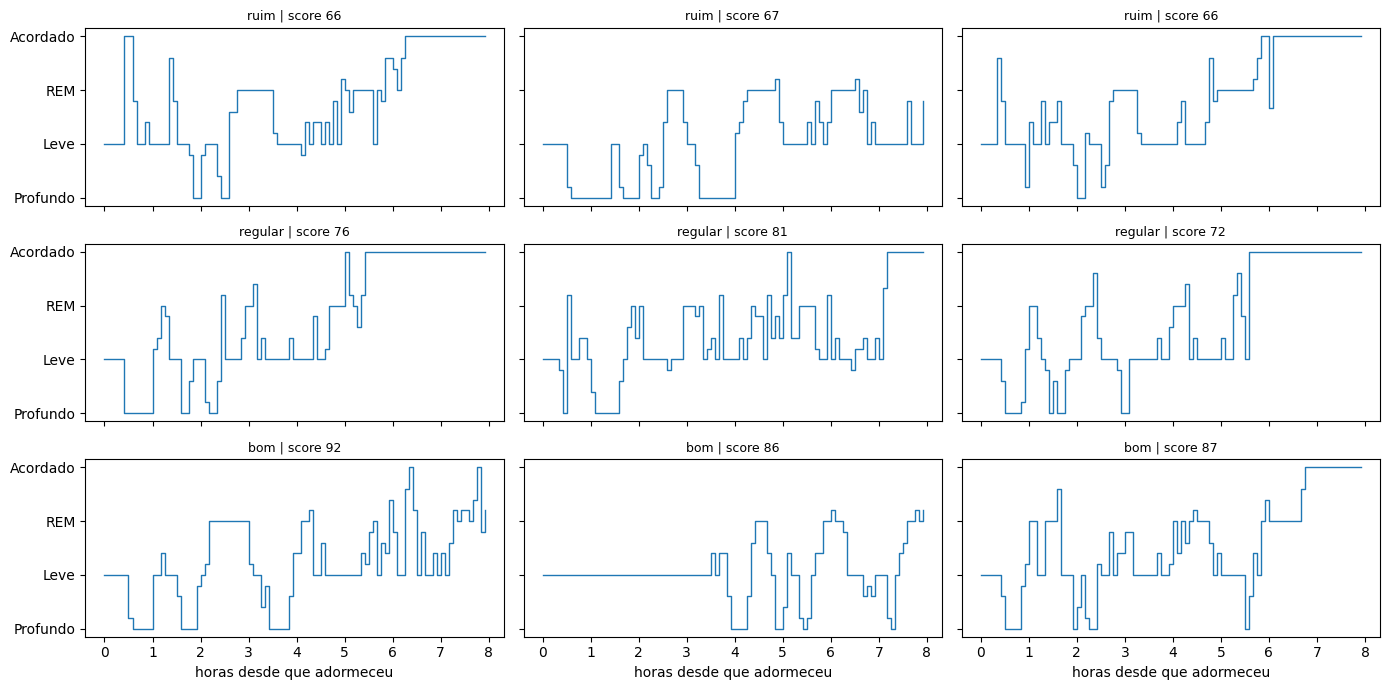

In [11]:
# Exemplos de hipnograma: 3 noites de treino sorteadas de cada classe
horas = np.arange(N_PONTOS) * EPOCA_MIN / 60
rng = np.random.default_rng(SEMENTE)
fig, eixos = plt.subplots(3, 3, figsize=(14, 7), sharex=True, sharey=True)
for lin, classe in enumerate(CLASSES):
    indices = rng.choice(np.where(y_treino == classe)[0], 3, replace=False)
    for col, i in enumerate(indices):
        ax = eixos[lin, col]
        ax.step(horas, X_treino[i, 0], where="post", lw=1)
        ax.set_title(f"{classe} | score {treino.sleep_score.iloc[i]:.0f}", fontsize=9)
        ax.set_yticks(range(4), NOMES_ESTAGIOS)
        ax.invert_yaxis()          # convenção do hipnograma: 'acordado' no topo
for ax in eixos[-1]:
    ax.set_xlabel("horas desde que adormeceu")
plt.tight_layout(); plt.show()

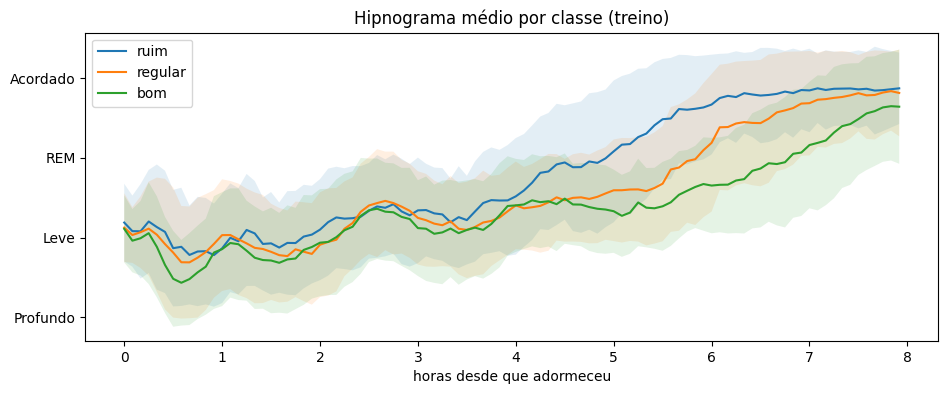

In [12]:
# Perfil médio de cada classe: média da profundidade em cada instante (faixa = ±1 desvio-padrão)
plt.figure(figsize=(11, 4))
for classe in CLASSES:
    s = X_treino[y_treino == classe, 0]
    media, dp = s.mean(axis=0), s.std(axis=0)
    plt.plot(horas, media, label=classe)
    plt.fill_between(horas, media - dp, media + dp, alpha=0.12)
plt.yticks(range(4), NOMES_ESTAGIOS); plt.gca().invert_yaxis()
plt.xlabel("horas desde que adormeceu"); plt.title("Hipnograma médio por classe (treino)")
plt.legend(); plt.show()

## 4. Pré-processamento

As etapas de segmentação (épocas de 5 min), *trimming* e *padding* (janela fixa de 8 h) já foram aplicadas na construção.

**Normalização:** optamos por **não** aplicar a normalização z (média 0, desvio 1) em cada série. A escala aqui é a mesma para todas as noites (0 = acordado ... 3 = profundo) e o nível absoluto carrega informação: uma noite com muito sono profundo tem valores médios mais altos. A normalização z apagaria essa diferença, que é justamente o que distingue as classes.

## 5. Baseline: 1-Vizinho Mais Próximo com DTW (1NN-DTW)

O 1NN classifica uma noite de teste com o rótulo da noite de treino mais parecida. A "parecença" é medida pela DTW (*Dynamic Time Warping*), que permite alinhar as séries com pequenos deslocamentos no tempo (por exemplo, a mesma fase de sono profundo acontecendo 20 minutos mais tarde).

**Parâmetro avaliado: largura da janela de Sakoe-Chiba**, que limita quanto a DTW pode deslocar os pontos (0 = sem deslocamento, equivalente à distância euclidiana; 1,0 = sem limite). A escolha é feita **só com o treino**, por validação *leave-one-out*: cada noite de treino é classificada pelas demais. O conjunto de teste só é usado depois, uma única vez.

janela = 0.00 (   0 min) -> acurácia LOO = 0.496
janela = 0.05 (  24 min) -> acurácia LOO = 0.587


janela = 0.10 (  48 min) -> acurácia LOO = 0.598


janela = 0.20 (  96 min) -> acurácia LOO = 0.512


janela = 0.30 ( 144 min) -> acurácia LOO = 0.457


janela = 1.00 ( 480 min) -> acurácia LOO = 0.446

Janela selecionada: 0.1


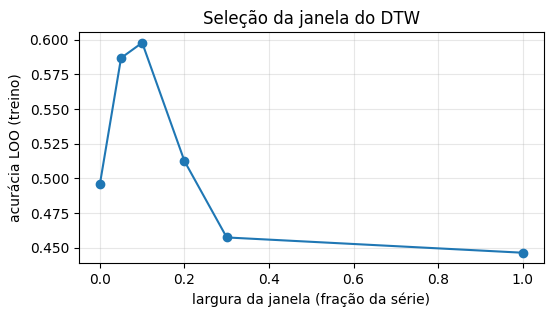

In [13]:
janelas = [0.0, 0.05, 0.10, 0.20, 0.30, 1.0]
acc_loo = {}
for w in janelas:
    D = dtw_pairwise_distance(X_treino, window=w)   # distâncias DTW entre todas as noites de treino
    np.fill_diagonal(D, np.inf)                     # uma noite não pode ser vizinha de si mesma
    vizinho = D.argmin(axis=1)                      # índice da noite mais parecida
    acc_loo[w] = (y_treino[vizinho] == y_treino).mean()
    print(f"janela = {w:.2f} ({w*JANELA_HORAS*60:>4.0f} min) -> acurácia LOO = {acc_loo[w]:.3f}")

melhor_janela = max(acc_loo, key=acc_loo.get)       # em caso de empate, fica a menor janela
print(f"\nJanela selecionada: {melhor_janela}")

plt.figure(figsize=(6, 3))
plt.plot(list(acc_loo), list(acc_loo.values()), marker="o")
plt.xlabel("largura da janela (fração da série)"); plt.ylabel("acurácia LOO (treino)")
plt.title("Seleção da janela do DTW"); plt.grid(alpha=.3); plt.show()

In [14]:
# Treina o 1NN-DTW com a janela escolhida e avalia no teste
nn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw",
                                        distance_params={"window": melhor_janela})
nn_dtw.fit(X_treino, y_treino)
pred_dtw = nn_dtw.predict(X_teste)
print(f"Acurácia 1NN-DTW no teste: {accuracy_score(y_teste, pred_dtw):.3f}")

Acurácia 1NN-DTW no teste: 0.536


## 6. Classificador escolhido: MiniRocket

O **MiniRocket** transforma cada série em milhares de atributos aplicando pequenos filtros de convolução (kernels) de tamanhos e dilatações variados. Cada kernel funciona como um "detector de padrão": mede em que proporção da noite aquele padrão aparece (por exemplo, subidas rápidas para o sono profundo). Um classificador linear (regressão Ridge) aprende quais desses padrões separam as classes. É um dos métodos mais precisos e rápidos da literatura de classificação de séries temporais, e por usar padrões locais tende a lidar bem com eventos que acontecem em horários diferentes a cada noite.

**Parâmetro avaliado: número de kernels**, escolhido por validação cruzada estratificada de 5 partes, **apenas no treino**.

In [15]:
opcoes_kernels = [1000, 5000, 10000]
validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
acc_cv = {}
for k in opcoes_kernels:
    notas = []
    for idx_tr, idx_val in validacao.split(X_treino, y_treino):
        modelo = MiniRocketClassifier(n_kernels=k, random_state=SEMENTE)
        modelo.fit(X_treino[idx_tr], y_treino[idx_tr])
        notas.append(accuracy_score(y_treino[idx_val], modelo.predict(X_treino[idx_val])))
    acc_cv[k] = np.mean(notas)
    print(f"n_kernels = {k:>5} -> acurácia média CV = {acc_cv[k]:.3f} (±{np.std(notas):.3f})")

melhor_k = max(acc_cv, key=acc_cv.get)
print(f"\nNúmero de kernels selecionado: {melhor_k}")

n_kernels =  1000 -> acurácia média CV = 0.663 (±0.093)


n_kernels =  5000 -> acurácia média CV = 0.658 (±0.067)


n_kernels = 10000 -> acurácia média CV = 0.628 (±0.061)

Número de kernels selecionado: 1000


In [16]:
# Treina com todo o treino usando o parâmetro escolhido e avalia no teste
minirocket = MiniRocketClassifier(n_kernels=melhor_k, random_state=SEMENTE)
minirocket.fit(X_treino, y_treino)
pred_mr = minirocket.predict(X_teste)
print(f"Acurácia MiniRocket no teste: {accuracy_score(y_teste, pred_mr):.3f}")

Acurácia MiniRocket no teste: 0.686


## 7. Resultados

Além dos dois modelos, incluímos a **classe majoritária** (sempre prever a classe mais comum no treino) como referência mínima: um modelo útil precisa superá-la.

In [17]:
classe_majoritaria = pd.Series(y_treino).value_counts().idxmax()
pred_maj = np.full(len(y_teste), classe_majoritaria)

tabela = pd.DataFrame({
    "modelo": [f"Classe majoritária ('{classe_majoritaria}')", "1NN-DTW (baseline)", "MiniRocket"],
    "parâmetro": ["-", f"janela = {melhor_janela}", f"n_kernels = {melhor_k}"],
    "acurácia no teste": [accuracy_score(y_teste, p) for p in (pred_maj, pred_dtw, pred_mr)],
}).round(3)
display(tabela)

,modelo,parâmetro,acurácia no teste
0,Classe majoritária ('regular'),-,0.473
1,1NN-DTW (baseline),janela = 0.1,0.536
2,MiniRocket,n_kernels = 1000,0.686


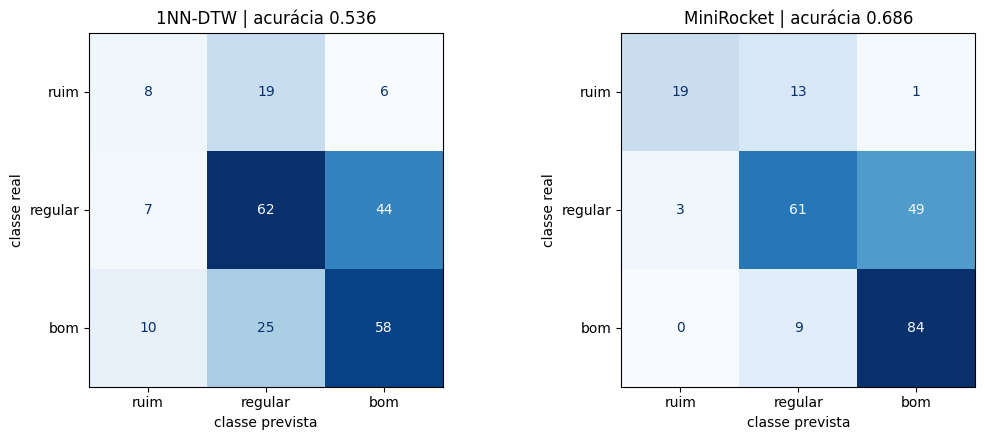

In [18]:
# Matrizes de confusão lado a lado (linhas = classe real, colunas = classe prevista)
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nome, pred) in zip(eixos, [("1NN-DTW", pred_dtw), ("MiniRocket", pred_mr)]):
    cm = confusion_matrix(y_teste, pred, labels=CLASSES)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{nome} | acurácia {accuracy_score(y_teste, pred):.3f}")
    ax.set_xlabel("classe prevista"); ax.set_ylabel("classe real")
plt.tight_layout(); plt.show()

In [19]:
# Precisão, revocação (recall) e F1 por classe
for nome, pred in [("1NN-DTW", pred_dtw), ("MiniRocket", pred_mr)]:
    print(f"===== {nome} =====")
    print(classification_report(y_teste, pred, labels=CLASSES, digits=3, zero_division=0))

===== 1NN-DTW =====
              precision    recall  f1-score   support

        ruim      0.320     0.242     0.276        33
     regular      0.585     0.549     0.566       113
         bom      0.537     0.624     0.577        93

    accuracy                          0.536       239
   macro avg      0.481     0.472     0.473       239
weighted avg      0.530     0.536     0.530       239

===== MiniRocket =====
              precision    recall  f1-score   support

        ruim      0.864     0.576     0.691        33
     regular      0.735     0.540     0.622       113
         bom      0.627     0.903     0.740        93

    accuracy                          0.686       239
   macro avg      0.742     0.673     0.684       239
weighted avg      0.711     0.686     0.678       239



In [20]:
# A diferença entre os modelos é estatisticamente significativa? (teste de McNemar exato)
# Só interessam as noites em que os modelos discordam: quantas o MiniRocket acertou e o
# 1NN-DTW errou (b), e o contrário (c). Se os modelos fossem equivalentes, b e c seriam
# parecidos (como cara ou coroa).
acerto_dtw, acerto_mr = pred_dtw == y_teste, pred_mr == y_teste
b = int(np.sum(acerto_mr & ~acerto_dtw))
c = int(np.sum(~acerto_mr & acerto_dtw))
p_valor = binomtest(b, b + c, 0.5).pvalue
print(f"Só o MiniRocket acertou: {b} | só o 1NN-DTW acertou: {c} | p-valor = {p_valor:.4f}")
print("Diferença significativa ao nível de 5%." if p_valor < 0.05 else
      "Diferença NÃO significativa ao nível de 5%.")

Só o MiniRocket acertou: 57 | só o 1NN-DTW acertou: 21 | p-valor = 0.0001
Diferença significativa ao nível de 5%.


## 8. Análise dos erros

Duas hipóteses para entender os erros:
1. **Os erros são entre classes vizinhas?** Confundir `ruim` com `regular` é mais aceitável do que confundir `ruim` com `bom`.
2. **Os erros se concentram perto dos limites de score (69/70 e 84/85)?** Uma noite com score 84 e outra com 86 são praticamente iguais, mas recebem rótulos diferentes.

In [21]:
ordem = {c: i for i, c in enumerate(CLASSES)}   # ruim=0, regular=1, bom=2
for nome, pred in [("1NN-DTW", pred_dtw), ("MiniRocket", pred_mr)]:
    salto = np.abs(np.vectorize(ordem.get)(pred) - np.vectorize(ordem.get)(y_teste))
    print(f"{nome}: {np.sum(salto == 1)} erros entre classes vizinhas | "
          f"{np.sum(salto == 2)} erros extremos (ruim <-> bom)")

1NN-DTW: 95 erros entre classes vizinhas | 16 erros extremos (ruim <-> bom)
MiniRocket: 74 erros entre classes vizinhas | 1 erros extremos (ruim <-> bom)


In [22]:
# Distância de cada noite de teste ao limite de score mais próximo
limites = np.array([69.5, 84.5])
teste["dist_limite"] = np.abs(teste["sleep_score"].to_numpy()[:, None] - limites).min(axis=1)
teste["faixa"] = pd.cut(teste["dist_limite"], [0, 3, 7, 100],
                        labels=["até 3 pontos", "3 a 7 pontos", "mais de 7 pontos"])
teste["acerto_dtw"], teste["acerto_mr"] = acerto_dtw, acerto_mr

display(teste.groupby("faixa", observed=True)
             .agg(noites=("classe", "size"),
                  acuracia_1nn_dtw=("acerto_dtw", "mean"),
                  acuracia_minirocket=("acerto_mr", "mean")).round(3))

,noites,acuracia_1nn_dtw,acuracia_minirocket
faixa,,,
até 3 pontos,93,0.538,0.634
3 a 7 pontos,99,0.515,0.657
mais de 7 pontos,47,0.574,0.851


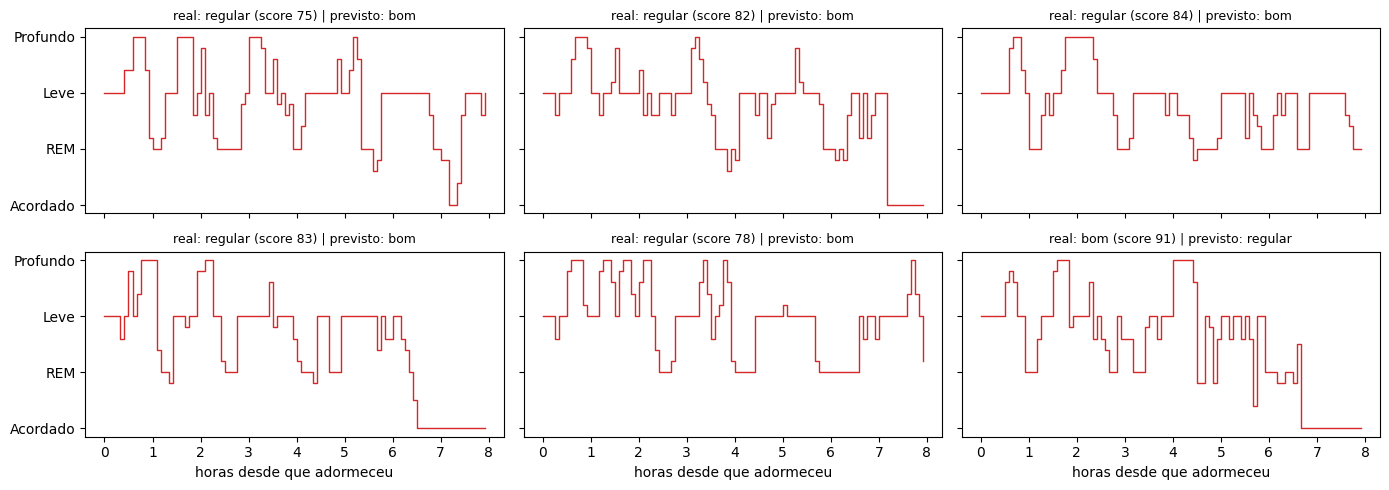

In [23]:
# Exemplos de erros do MiniRocket: hipnograma, classe real e prevista
erros = np.where(~acerto_mr)[0][:6]
fig, eixos = plt.subplots(2, 3, figsize=(14, 5), sharex=True, sharey=True)
for ax, i in zip(eixos.ravel(), erros):
    ax.step(horas, X_teste[i, 0], where="post", lw=1, color="tab:red")
    ax.set_title(f"real: {y_teste[i]} (score {teste.sleep_score.iloc[i]:.0f}) | previsto: {pred_mr[i]}",
                 fontsize=9)
    ax.set_yticks(range(4), NOMES_ESTAGIOS); ax.invert_yaxis()
for ax in eixos[-1]:
    ax.set_xlabel("horas desde que adormeceu")
plt.tight_layout(); plt.show()

## 9. Limitações

**Coleta**
- **Um único usuário e um único dispositivo.** O modelo aprende o padrão de sono de uma pessoa específica e não deve generalizar para outras pessoas nem para outros relógios.
- **O estágio do sono é uma estimativa do relógio**, feita a partir de movimento e frequência cardíaca, e não uma polissonografia. Erros do algoritmo da Samsung entram diretamente nas séries; em poucas noites aparecem trechos longos e contínuos de um único estágio (horas seguidas de sono leve), provavelmente falhas de classificação do relógio.
- **Cobertura irregular:** só uma parte das noites do período foi registrada (dias sem uso do relógio), e a cobertura cai ao longo do tempo. As noites registradas podem não representar todas as noites.

**Rótulos**
- **Os rótulos vêm de outro algoritmo.** O sleep score é calculado pela Samsung a partir desses mesmos estágios e de outras variáveis (movimento, latência). O modelo, na prática, aprende a imitar esse cálculo, e há uma relação parcialmente circular entre entrada e rótulo.
- **Limites arbitrários:** transformar um score contínuo em 3 classes cria fronteiras artificiais (84 é `regular`, 85 é `bom`), e boa parte dos erros acontece perto delas (seção 8).
- **Possível mudança no algoritmo do app:** atualizações do Samsung Health podem ter alterado o cálculo do score ou dos estágios ao longo dos 3 anos, mudando o significado dos rótulos entre treino e teste.

**Protocolo e modelo**
- **Mudança de distribuição:** a divisão temporal é mais realista, mas a proporção de classes muda entre treino (mais noites `ruim`) e teste (menos). O modelo é avaliado num "período diferente" do que aprendeu.
- **Dependência entre noites:** noites consecutivas não são totalmente independentes (rotina, fins de semana). A divisão temporal reduz, mas não elimina, esse efeito dentro de cada conjunto.
- **Janela fixa de 8 h:** noites mais longas perdem o final, e o preenchimento com "acordado" faz a duração pesar bastante na classificação.
- **Representação ordinal dos estágios:** codificar acordado/REM/leve/profundo como 0 a 3 supõe uma ordem e distâncias iguais entre estágios, o que é uma simplificação (o REM, por exemplo, é fisiologicamente próximo da vigília em alguns aspectos).

**Possíveis melhorias:** usar séries multivariadas (hipnograma + frequência cardíaca + movimento), tratar o problema como regressão do score, coletar dados de mais pessoas e comparar com uma divisão aleatória para medir o efeito da dependência temporal.